In [26]:
import warnings
from typing import Dict, Tuple, List, Optional
import os

import pandas as pd
import numpy as np
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# try importing post_masking (optional)
try:
    from SynOmics.processing.postprocessing import post_masking
except Exception:
    post_masking = None
    warnings.warn("post_masking not available. If you need masking, ensure SynOmics is on PYTHONPATH.")



def response_rate_logit(x,y):
    log_reg = sm.Logit(y,sm.add_constant(x)).fit(method='lbfgs',maxiter=99999,disp=0)
    return log_reg.pvalues,log_reg.params

def harmonize_signature(dataset, is_original = True):
    if is_original:
        clinical_data = "original_data"
        signature_data = 'Origin'
    else:
        clinical_data = dataset
        signature_data = dataset
        
    un_mask_su2c_clinical = pd.read_csv(f'../NSCLC/Data/{clinical_data}.csv').iloc[:,0:29]
    su2c_clinical = post_masking(un_mask_su2c_clinical)
    su2c_clinical = su2c_clinical.rename(columns= {
        'Patient_ID': 'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'
    })
    su2c_clinical['Harmonized_Confirmed_BOR_Bin'] = su2c_clinical['Harmonized_Confirmed_BOR_3_Cat'].map({
        'PR/CR': 1, 'CR/PR': 1, 'PR': 1, 'CR': 1,
        'SD': 0, 'PD': 0
    })

    su2c_is_sf_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/SF_{signature_data}.csv')
    su2c_is_sf_harm = su2c_is_sf_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})
    
    su2c_is_zi_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/ZI_{signature_data}.csv')
    su2c_is_zi_harm = su2c_is_zi_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})
    
    su2c_is_hm_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/Other_{signature_data}.csv')
    su2c_is_hm_harm = su2c_is_hm_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})


    su2c_merge_master = su2c_clinical.merge(su2c_is_hm_harm.rename(columns = lambda x: x + '_HM'),\
              left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',how='left')\
              .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',axis=1)\
        .merge(su2c_is_sf_harm.rename(columns = lambda x: x + '_SF'),\
              left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',how='left')\
              .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',axis=1)\
        .merge(su2c_is_zi_harm.rename(columns = lambda x: x + '_ZI'),\
              left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
              .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)

    return su2c_merge_master


def fit_logit(df_merge, selected_cols):
    log_reg = []
    df = pd.DataFrame()
    df_test = df_merge
    for feature in selected_cols:
        X = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2').loc[:,[feature]]
        if X.iloc[:,0].dtype.name!='float64':
            Xd = pd.get_dummies(X,dummy_na=True).iloc[:,0:-1]
            df = pd.concat([df,Xd],axis=1)
            for col in Xd.columns:
                y = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2')['Harmonized_Confirmed_BOR_Bin']
                Xi = Xd[[col]]
                Xy = Xi.merge(y,left_index=True,right_index=True,how='inner').dropna()
                Xi = Xy.iloc[:,[0]]
                y = Xy.iloc[:,[1]]
                p, param = response_rate_logit(Xi,y)
                log_reg.append([Xi.columns[0],p[1],param[1]])
        else:
            df = pd.concat([df,X],axis=1)
            y = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2')['Harmonized_Confirmed_BOR_Bin']
            Xy = X.merge(y,left_index=True,right_index=True,how='inner').dropna()
            X = Xy.iloc[:,[0]]
            y = Xy.iloc[:,[1]]
            p, param = response_rate_logit(X,y)
            log_reg.append([feature,p[1],param[1]])
    log_reg_df = pd.DataFrame(log_reg,columns=['Feature','p_value','coeff']).set_index('Feature')

    return log_reg_df

In [31]:

results_by_dataset = {}
dataset = "Origin"
df_master = harmonize_signature(dataset, is_original = True)

selected_cols = select_cols = ['B-cells_SF',
 'Cytotoxic cells_SF',
 'DC_SF',
 'Exhausted CD8_SF',
 'Exhausted/HS CD8_SF',
 'Lymphocytes_SF',
 'Lymphocytes exhausted/cell cycle_SF',
 'Macrophages/Monocytes_SF',
 'Memory T cells_SF',
 'Plasma_SF',
 'Treg_SF']
log_reg_df = fit_logit(df_master, selected_cols)

results_by_dataset['Origin'] = log_reg_df

seed = 42
datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}', f'ctgan_{seed}', f'gaussiancopula_{seed}', f'synthpop_{seed}', f'tvae_{seed}']
names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussia Copula', 'Synthpop', 'TVAE']
for i, dataset in enumerate(datasets):
    df_master = harmonize_signature(dataset, is_original = False)
    log_reg_df = fit_logit(df_master, selected_cols)
    results_by_dataset[names[i]] = log_reg_df



In [33]:
def strip_feature_suffix_in_results(
    results_by_dataset: dict,
    suffix: str = "_SF",
    only_if_suffix: bool = True,
) -> dict:
    out = {}
    for ds, df in results_by_dataset.items():
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Value for dataset '{ds}' is not a pandas DataFrame: {type(df)}")

        new_df = df.copy()
        idx = new_df.index.astype(str)

        if only_if_suffix:
            new_df.index = idx.str.replace(f"{suffix}$", "", regex=True)
        else:
            new_df.index = idx.str.replace(suffix, "", regex=False)

        out[ds] = new_df

    return out
    
results_by_dataset_no_sf = strip_feature_suffix_in_results(results_by_dataset, suffix="_SF")

# Check
print(list(results_by_dataset_no_sf.values())[0].index[:10])

Index(['B-cells', 'Cytotoxic cells', 'DC', 'Exhausted CD8', 'Exhausted/HS CD8',
       'Lymphocytes', 'Lymphocytes exhausted/cell cycle',
       'Macrophages/Monocytes', 'Memory T cells', 'Plasma'],
      dtype='object', name='Feature')


In [82]:
from typing import Dict, Tuple, List, Optional, Callable
import warnings
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Consistent color definitions used across SynOmics visualizations
DATA_COLORS = {"real": "#4c72b0", "synthetic": "#dd8452"}
PVAL_BIN_COLORS_DEFAULT = ["#d62728", "#ff7f0e", "#1f77b4", "#cccccc"]  # red, orange, blue, gray


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Strip whitespace from dataframe column names.
    """
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def _resolve_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    """
    Resolve a column name from a list of candidate aliases.
    """
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None


def plot_pathway(
    ssGSEA_comparison: Dict[str, pd.DataFrame],
    ref_pathway_list: List[str],
    highlight_pathways: Optional[List[str]] = None,
    origin_name: str = "Origin",
    term_col: str = "Term",
    pval_col: str = "adj_pvalues",
    diff_col: str = "Diff_NES",
    # shorten_terms: bool = True,
    term_formatter: Optional[Callable[[str], str]] = None,
    pval_bin_colors: List[str] = PVAL_BIN_COLORS_DEFAULT,
    dataset_colors: Optional[Dict[str, str]] = None,
    figsize: Optional[Tuple[float, float]] = None,
    fig_width_min: float = 14.0,
    bubble_size: float = 170.0,
    title_pad: float = 14.0,
    dataset_strip_y: float = 1.01,
    dataset_strip_lw: float = 4.0,
    dataset_strip_pad: float = 0.0,
    show: bool = True,
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
    allow_column_aliases: bool = True,
    # New options:
    order_by: str = "pvalue",  # "pvalue" (default) or "diff"
    order_ascending: bool = True,  # when ordering by diff, ascending if True
    negative_shade: bool = True,
    negative_shade_color: str = "#e6f2ff",
    negative_shade_alpha: float = 0.12,
    # Layout control (new):
    ncols: int = 3,
    nrows: Optional[int] = None,
    # x limits and outlier handling (symmetric)
    xlim: Optional[Tuple[float, float]] = None,
) -> Tuple[plt.Figure, Optional[pd.DataFrame]]:
    """
    Plot a pathway bubble scatter plot from ssGSEA comparison results (Term, Diff_NES, adjusted p-value).

    New options:
        - order_by: "pvalue" (default) or "diff" to order y-axis terms using diff_col in origin dataset.
        - order_ascending: when order_by="diff", sort ascending if True (most negative first).
        - negative_shade: if True, shade the negative side (x < 0).
        - ncols/nrows: grid layout control.
        - xlim: optional symmetric x-limit. If provided, the plot will keep symmetry around 0:
            * If xlim is a scalar (e.g. 2.0) -> use [-2.0, 2.0].
            * If xlim is a tuple, we take max(abs(x0), abs(x1)) and use [-max, +max].
          Values outside the symmetric range are clipped to the boundary and flagged as outliers
          in the returned dataframe (is_outlier=True). The plot remains symmetric.
    """
    if not ssGSEA_comparison:
        raise ValueError("ssGSEA_comparison must not be empty.")
    if not ref_pathway_list:
        raise ValueError("ref_pathway_list must not be empty.")
    if highlight_pathways is None:
        highlight_pathways = []

    # normalize any whitespace in provided column-name arguments so aliases match sanitized df columns
    if isinstance(term_col, str):
        term_col = term_col.strip()
    if isinstance(pval_col, str):
        pval_col = pval_col.strip()
    if isinstance(diff_col, str):
        diff_col = diff_col.strip()

    datasets = list(ssGSEA_comparison.keys())
    all_data_to_plot: List[pd.DataFrame] = []
    found_any = False

    term_candidates = [term_col, "term", "Pathway", "pathway"]
    pval_candidates = [pval_col, "adj_pvalue", "adj.P.Val", "padj", "qvalue", "q-value", "FDR", "FDR q-val"]
    diff_candidates = [diff_col, "Diff_NES", "diff_nes", "NES_diff", "delta_NES", "NES", "nes", "Diff_Mean"]

    for ds_name in datasets:
        df_ds = ssGSEA_comparison.get(ds_name)
        if df_ds is None or not isinstance(df_ds, pd.DataFrame):
            warnings.warn(f"Skipping {ds_name}: not a pandas DataFrame.")
            continue

        df_ds = _normalize_columns(df_ds)

        if allow_column_aliases:
            term_resolved = _resolve_column(df_ds, term_candidates)
            pval_resolved = _resolve_column(df_ds, pval_candidates)
            diff_resolved = _resolve_column(df_ds, diff_candidates)
        else:
            term_resolved = term_col if term_col in df_ds.columns else None
            pval_resolved = pval_col if pval_col in df_ds.columns else None
            diff_resolved = diff_col if diff_col in df_ds.columns else None

        missing = []
        if term_resolved is None:
            missing.append(term_col)
        if pval_resolved is None:
            missing.append(pval_col)
        if diff_resolved is None:
            missing.append(diff_col)

        if missing:
            warnings.warn(
                f"Skipping {ds_name}: missing required columns: {missing}. "
                f"Available columns: {list(df_ds.columns)}"
            )
            continue

        sub_df = df_ds[df_ds[term_resolved].isin(ref_pathway_list)].copy()
        if sub_df.empty:
            warnings.warn(f"Skipping {ds_name}: none of ref_pathway_list terms were found.")
            continue

        found_any = True

        # rename resolved columns into canonical names or into diff_col name for flexibility
        sub_df = sub_df.rename(
            columns={
                term_resolved: "Term",
                pval_resolved: "adj_pvalues",
                diff_resolved: diff_col,
            }
        )
        sub_df["Dataset"] = ds_name

        sub_df["adj_pvalues"] = pd.to_numeric(sub_df["adj_pvalues"], errors="coerce")
        sub_df[diff_col] = pd.to_numeric(sub_df[diff_col], errors="coerce").fillna(0.0)

        sub_df["-log10(qvalue)"] = -np.log10(sub_df["adj_pvalues"].clip(lower=np.nextafter(0, 1)))

        all_data_to_plot.append(sub_df[["Dataset", "Term", "adj_pvalues", diff_col, "-log10(qvalue)"]])

    if not found_any:
        raise ValueError("No dataset contained required columns and at least one requested pathway.")

    df_plot = pd.concat(all_data_to_plot, ignore_index=True)

    present = set(df_plot["Term"].unique())
    y_terms = [p for p in ref_pathway_list if p in present]
    if not y_terms:
        raise ValueError("None of the pathways in ref_pathway_list were found after filtering.")

    # If origin dataset exists, reorder pathways based on user's order_by choice
    origin_df = df_plot[df_plot["Dataset"] == origin_name].copy()
    if not origin_df.empty:
        if order_by == "diff":
            origin_df = origin_df.sort_values(by=diff_col, ascending=order_ascending, na_position="last")
        else:
            origin_df = origin_df.sort_values(by="adj_pvalues", ascending=True, na_position="last")

        origin_sorted = origin_df["Term"].tolist()
        merged = []
        for t in origin_sorted + list(ref_pathway_list):
            if (t in ref_pathway_list) and (t in present) and (t not in merged):
                merged.append(t)
        y_terms = merged

    # Display labels (shortened)
    if term_formatter is not None:
        y_labels = [term_formatter(t) for t in y_terms]
    else:
        y_labels = list(y_terms)

    mapping = {term: idx for idx, term in enumerate(y_terms)}
    y_pos = np.arange(len(y_terms))

    max_abs_nes = np.nanmax(np.abs(df_plot[diff_col].to_numpy(dtype=float)))
    if not np.isfinite(max_abs_nes) or max_abs_nes == 0:
        max_abs_nes = 1.0

    # determine x limits (use provided xlim if given) but enforce symmetry around 0
    if xlim is None:
        x_left = -max_abs_nes * 1.05
        x_right = max_abs_nes * 1.05
    else:
        try:
            # allow xlim to be scalar (single positive value) or sequence/tuple
            if isinstance(xlim, (int, float)):
                maxval = abs(float(xlim))
            else:
                x0 = float(xlim[0])
                x1 = float(xlim[1])
                maxval = max(abs(x0), abs(x1))
            if not np.isfinite(maxval) or maxval == 0:
                maxval = max_abs_nes * 1.05 if (np.isfinite(max_abs_nes) and max_abs_nes > 0) else 1.0
            # enforce symmetric limits around zero
            x_left = -maxval
            x_right = maxval
        except Exception as e:
            raise ValueError(f"Invalid xlim value: {xlim}. Error: {e}")

    # mark outliers and compute clipped x for plotting (clipped to symmetric bounds)
    df_plot["_x_orig"] = df_plot[diff_col].astype(float)
    df_plot["_is_outlier"] = (df_plot["_x_orig"] < x_left) | (df_plot["_x_orig"] > x_right)
    df_plot["x_plot"] = df_plot["_x_orig"].clip(lower=x_left, upper=x_right)

    bins = [0, 0.01, 0.05, 0.25, 1.01]
    bin_labels = ["p<0.01", "0.01≤p<0.05", "0.05≤p<0.25", "p≥0.25"]
    color_map = dict(zip(bin_labels, pval_bin_colors))

    df_plot["pvalue_bin"] = pd.cut(
        df_plot["adj_pvalues"],
        bins=bins,
        labels=bin_labels,
        include_lowest=True,
        right=False,
    )

    # Layout: use ncols/nrows provided; expand rows if necessary to fit datasets
    if nrows is None:
        nrows = 2
    n_datasets = len(datasets)
    if n_datasets > ncols * nrows:
        nrows = math.ceil(n_datasets / ncols)
        warnings.warn(f"Number of datasets ({n_datasets}) > {ncols*nrows}, expanding to {nrows} rows x {ncols} cols.")

    if figsize is None:
        fig_width = max(3.5 * ncols + 2, fig_width_min)
        fig_height = max(0.6 * len(y_terms) + 3, 7) if nrows <= 2 else max(0.6 * len(y_terms) + 3, 7) * (nrows / 2)
        figsize = (fig_width, fig_height)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True, sharex=True)
    axes_list = list(np.array(axes).flatten())

    plt.subplots_adjust(left=0.28, right=0.88, top=0.92, bottom=0.06, hspace=0.28, wspace=0.18)

    highlight_set = set(highlight_pathways or [])

    for i, ds in enumerate(datasets):
        if i >= len(axes_list):
            warnings.warn(f"Not enough subplot axes for dataset '{ds}'; skipping.")
            continue
        ax = axes_list[i]
        sub = df_plot[df_plot["Dataset"] == ds].copy()
        sub["y"] = sub["Term"].map(mapping)

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10, color="grey", transform=ax.transAxes)
            ax.set_xlim(x_left, x_right)
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.tick_params(left=False, labelleft=False)
        else:
            # shade negative side if requested
            if negative_shade:
                ax.axvspan(x_left, min(0.0, x_right), color=negative_shade_color, alpha=negative_shade_alpha, zorder=0)

            # Priority drawing:
            # draw non-significant (adj_pvalues >= 0.25) first, then significant (adj_pvalues < 0.25)
            sig_mask = sub["adj_pvalues"] < 0.25
            non_sig = sub[~sig_mask]
            sig = sub[sig_mask]

            # draw non-significant first (lower zorder)
            if not non_sig.empty:
                ax.scatter(
                    x=non_sig["x_plot"],
                    y=non_sig["y"],
                    s=bubble_size,
                    c=non_sig["pvalue_bin"].map(color_map).fillna("#cccccc"),
                    edgecolor="k",
                    linewidths=0.4,
                    alpha=0.95,
                    zorder=2,
                )
            # then draw significant on top (higher zorder)
            if not sig.empty:
                ax.scatter(
                    x=sig["x_plot"],
                    y=sig["y"],
                    s=bubble_size,
                    c=sig["pvalue_bin"].map(color_map).fillna("#cccccc"),
                    edgecolor="k",
                    linewidths=0.8,
                    alpha=0.98,
                    zorder=3,
                )

            ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
            ax.set_xlim(x_left, x_right)
            ax.set_xlabel(diff_col, fontsize=9, labelpad=6)

            ax.set_yticks(y_pos)
            ax.set_ylim(-0.5, len(y_terms) - 0.5)
            ax.invert_yaxis()
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

            # Determine grid column for this axis so left-column axes show y labels
            col_idx = i % ncols
            if col_idx == 0:
                # leftmost column: show y tick labels
                ax.set_yticklabels(y_labels, fontsize=9)
                ax.tick_params(axis="y", which="major", pad=6, left=True, labelleft=True)
                for j, label in enumerate(ax.get_yticklabels()):
                    term = y_terms[j]
                    if term in highlight_set:
                        label.set_color(DATA_COLORS["real"])
                        label.set_fontweight("bold")
                    else:
                        label.set_color("black")
            else:
                # other columns: hide y tick labels
                ax.tick_params(left=False, labelleft=False)

        # dataset color strip
        if dataset_colors is not None:
            strip_color = dataset_colors.get(ds, "#333333")
            y_strip = dataset_strip_y + dataset_strip_pad
            ax.plot(
                [0.08, 0.92],
                [y_strip, y_strip],
                transform=ax.transAxes,
                color=strip_color,
                lw=dataset_strip_lw,
                clip_on=False,
                solid_capstyle="round",
            )

    # Hide any unused axes if fewer datasets than grid cells
    for j in range(len(datasets), len(axes_list)):
        ax_unused = axes_list[j]
        ax_unused.set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 0.88, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    df_plot["y"] = df_plot["Term"].map(mapping)
    # include clipped x and outlier flag in returned df
    df_plot = df_plot[["Dataset", "Term", "adj_pvalues", diff_col, "x_plot", "_x_orig", "_is_outlier", "-log10(qvalue)", "y", "pvalue_bin"]]
    df_plot = df_plot.rename(columns={"_x_orig": f"{diff_col}_orig", "_is_outlier": "is_outlier"})

    return (fig, df_plot) if return_dataframe else (fig, None)

In [59]:
import re
import warnings
from typing import Dict, List, Sequence, Optional

import numpy as np
import pandas as pd
from statsmodels.stats import multitest


def _df_logistic_to_plot_df(
    log_reg_df: pd.DataFrame,
    p_col_candidates=("p_value", "pval", "p.value", "p.value.", "pvalue"),
    coef_col_candidates=("coeff", "coef", "estimate", "Estimate"),
    suffix: Optional[str] = "_SF",
    only_if_suffix: bool = True,
) -> pd.DataFrame:
    """
    Convert a single logistic result DataFrame (index=feature, with p and coef columns)
    into a DataFrame with columns ['Term','adj_pvalues','coeff'] for one replicate.

    New params:
      - suffix: optional suffix to strip from feature names (default "_SF")
      - only_if_suffix: if True, only remove when suffix appears at the end; otherwise remove all occurrences

    The function looks for p and coef columns among p_col_candidates and coef_col_candidates.
    """
    df = log_reg_df.copy()
    # find p col
    pcol = next((c for c in p_col_candidates if c in df.columns), None)
    ccol = next((c for c in coef_col_candidates if c in df.columns), None)
    if pcol is None or ccol is None:
        raise ValueError(
            f"Could not find p/coef columns in logistic result. "
            f"Looked for {p_col_candidates} and {coef_col_candidates}. columns: {df.columns.tolist()}"
        )

    # get feature names from index (fall back to a 'Feature' column if present)
    if df.index is not None and len(df.index) > 0:
        terms = df.index.astype(str).tolist()
    elif "Term" in df.columns:
        terms = df["Term"].astype(str).tolist()
    elif "Feature" in df.columns:
        terms = df["Feature"].astype(str).tolist()
    else:
        # fallback: use numeric indices as strings
        terms = [str(i) for i in range(len(df))]

    # strip suffix if requested
    if suffix:
        if only_if_suffix:
            pattern = re.compile(re.escape(suffix) + r"$")
        else:
            pattern = re.compile(re.escape(suffix))
        terms = [pattern.sub("", t) for t in terms]

    pvals = pd.to_numeric(df[pcol], errors="coerce").astype(float)
    coeffs = pd.to_numeric(df[ccol], errors="coerce").astype(float)
    out = pd.DataFrame({"Term": terms, "adj_pvalues": pvals.values, "coeff": coeffs.values})
    return out


def build_comparison_from_replicates(
    origin_name: str,
    synth_name_map: Dict[str, str],
    seeds: Sequence[int],
    selected_cols: List[str],
    harmonize_signature_fn,
    fit_logit_fn,
    adjust_pvalues_per_replicate: bool = True,
    adjust_method: str = "fdr_bh",
    suffix: Optional[str] = "_SF",
    only_if_suffix: bool = True,
) -> Dict[str, pd.DataFrame]:
    """
    Build ssGSEA-like comparison dict for plot_pathway from many logistic replicates.
    """
    # prepare accumulator for origin + synthetic display names
    accum = {name: [] for name in ([origin_name] + list(synth_name_map.keys()))}

    # Origin: use provided harmonize_signature_fn and fit_logit_fn
    try:
        df_master_origin = harmonize_signature_fn(origin_name, is_original=True)
        origin_res = fit_logit_fn(df_master_origin, selected_cols)
        origin_plot_df = _df_logistic_to_plot_df(origin_res, suffix=suffix, only_if_suffix=only_if_suffix)
        origin_plot_df["_replicate"] = "origin"
        accum[origin_name].append(origin_plot_df)
    except Exception as e:
        warnings.warn(f"Origin processing failed: {e}")

    # Process synthetic datasets for each seed
    for seed in seeds:
        for display_name, template in synth_name_map.items():
            dataset_basename = template.format(seed=seed)
            try:
                df_master = harmonize_signature_fn(dataset_basename, is_original=False)
                log_reg_df = fit_logit_fn(df_master, selected_cols)
                plot_df = _df_logistic_to_plot_df(log_reg_df, suffix=suffix, only_if_suffix=only_if_suffix)

                # Optionally adjust p-values per-replicate
                if adjust_pvalues_per_replicate:
                    p = plot_df["adj_pvalues"].fillna(1.0).to_numpy()
                    try:
                        _, adj, _, _ = multitest.multipletests(p, method=adjust_method)
                        # replace only where original pvals were not NaN
                        adj_series = pd.Series(adj, index=plot_df.index).where(~plot_df["adj_pvalues"].isna(), other=np.nan)
                        plot_df["adj_pvalues"] = adj_series.values
                    except Exception:
                        # fallback leave raw pvalues
                        pass

                # annotate replicate id
                plot_df["_replicate"] = f"seed_{seed}"
                accum[display_name].append(plot_df)
            except Exception as e:
                warnings.warn(f"Skipping {display_name} (seed={seed}) due to error: {e}")

    # concat per dataset
    out = {}
    for name, dfs in accum.items():
        if not dfs:
            warnings.warn(f"No replicates collected for {name}; producing empty DataFrame.")
            out[name] = pd.DataFrame(columns=["Term", "adj_pvalues", "coeff", "_replicate"])
        else:
            out[name] = pd.concat(dfs, ignore_index=True)

    return out

In [60]:
# --- parameters you had ---
selected_cols = [
 'B-cells_SF','Cytotoxic cells_SF','DC_SF','Exhausted CD8_SF','Exhausted/HS CD8_SF',
 'Lymphocytes_SF','Lymphocytes exhausted/cell cycle_SF','Macrophages/Monocytes_SF',
 'Memory T cells_SF','Plasma_SF','Treg_SF'
]

# mapping display name -> dataset basename template (must accept {seed})
synth_name_map = {
    "Avatars K5": "avatarsk5_{seed}",
    "Avatars K10": "avatarsk10_{seed}",
    "CTGAN": "ctgan_{seed}",
    "Gaussian Copula": "gaussiancopula_{seed}",
    "Synthpop": "synthpop_{seed}",
    "TVAE": "tvae_{seed}",
}

# your seeds list (multiple seeds)
seeds = [0,1,2,3,42]  # example multiple replicates


comparison_dict = build_comparison_from_replicates(
    origin_name="Origin",
    synth_name_map=synth_name_map,
    seeds=seeds,
    selected_cols=selected_cols,
    harmonize_signature_fn=harmonize_signature,
    fit_logit_fn=fit_logit,
    adjust_pvalues_per_replicate=False,
    suffix="_SF",          
    only_if_suffix=True,
)

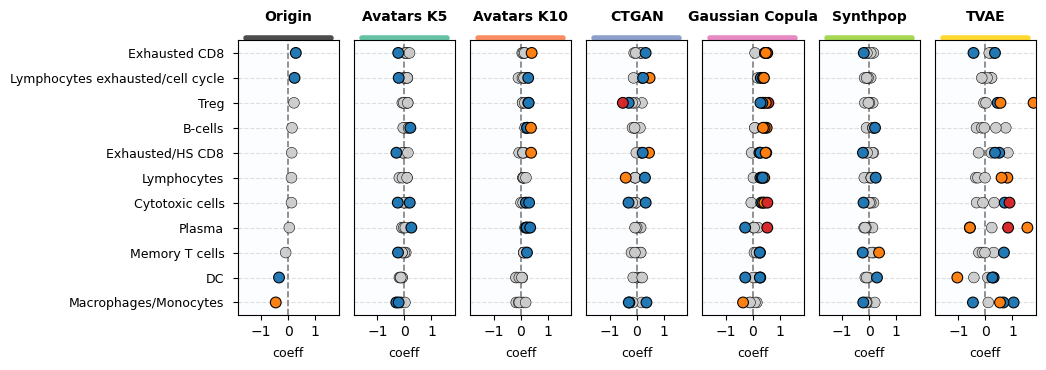

In [88]:
# Visual params
DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

# ref_pathway_list: the Terms to show on y-axis (use selected_cols)
# ref_pathway_list = selected_cols
ref_pathway_list = [t.replace("_SF", "") for t in selected_cols]
# call plot (ncols=7, nrows=1)
fig, df_plot = plot_pathway(
    ssGSEA_comparison=comparison_dict,
    ref_pathway_list=ref_pathway_list,
    origin_name="Origin",
    diff_col="coeff",
    figsize = (12,4),
    pval_col="adj_pvalues",
    dataset_colors=DATASET_COLORS,
    bubble_size = 60,
    ncols=7,
    nrows=1,
    order_by="diff",
    order_ascending=False,
    show=True,
    return_dataframe=True,
)
fig.savefig(
    "logisitc_NSCLC/SF_LogisticRegression.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

In [69]:
ZI_cells = [
    'hMø1_ZI', 'hMø4_ZI', 'hMø5_ZI', 'hMø6_ZI', 'hMø7_ZI', 'hMø8_ZI','hMø9_ZI', 'hMono1_ZI','hMono2_ZI', 'hMono3_ZI',
    'hN1_ZI',  'hN2_ZI', 'hN3_ZI',  'hN5_ZI', 'hDC1_ZI', 'hDC2_ZI', 'hDC3_ZI','hpDC_ZI']

comparison_dict_ZI = build_comparison_from_replicates(
    origin_name="Origin",
    synth_name_map=synth_name_map,
    seeds=seeds,
    selected_cols=ZI_cells,
    harmonize_signature_fn=harmonize_signature,
    fit_logit_fn=fit_logit,
    adjust_pvalues_per_replicate=False,
    suffix="_ZI",          
    only_if_suffix=True,
)

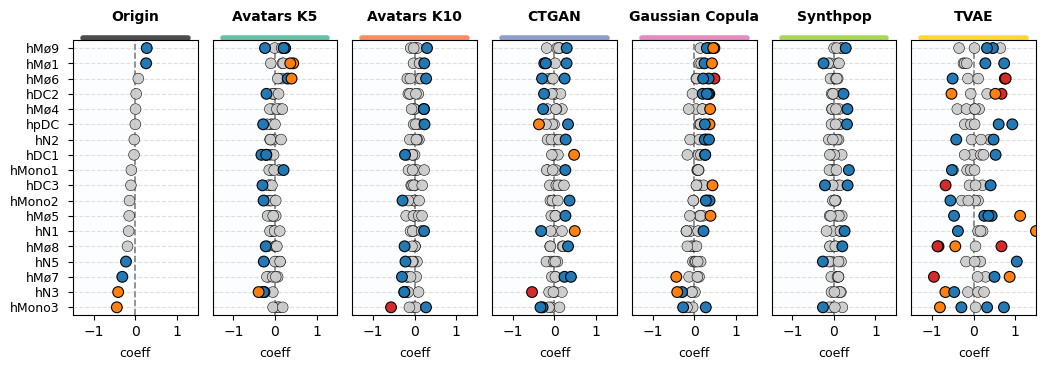

In [87]:
ref_pathway_zi = [t.replace("_ZI", "") for t in ZI_cells]
# call plot (ncols=7, nrows=1)
fig_zi, df_plot = plot_pathway(
    ssGSEA_comparison=comparison_dict_ZI,
    ref_pathway_list=ref_pathway_zi,
    origin_name="Origin",
    diff_col="coeff",
    figsize = (12,4),
    pval_col="adj_pvalues",
    dataset_colors=DATASET_COLORS,
    bubble_size = 60,
    ncols=7,
    nrows=1,
    order_by="diff",
    order_ascending=False,
    show=True,
    return_dataframe=True,
    xlim = (-1.5, 1.5)
)
fig_zi.savefig(
    "logisitc_NSCLC/ZI_LogisticRegression.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
